In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os
from tensorflow.keras.models import Model
from tensorflow.keras import layers, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

In [2]:
train_path = r"C:\Users\48668\Documents\jdszr18-Neuronauci\FER-2013_balanced\train"
test_path = r"C:\Users\48668\Documents\jdszr18-Neuronauci\FER-2013_balanced\test"
val_path = r"C:\Users\48668\Documents\jdszr18-Neuronauci\FER-2013_balanced\val"

In [3]:
target_size = (75, 75)
batch_size = 32
num_classes = 8

In [4]:
train_datagen = ImageDataGenerator(rescale=1./255,               # Normalize pixel values from [0, 255] to [0, 1]
                                    rotation_range=15,            # Randomly rotate images in the range of ±15 degrees
                                    width_shift_range=0.1,        # Randomly shift images horizontally by up to 10% of the width
                                    height_shift_range=0.1,       # Randomly shift images vertically by up to 10% of the height
                                    shear_range=0.1,              # Apply shear transformations (slanting the image)
                                    zoom_range=0.1,               # Randomly zoom in/out by up to 10%
                                    horizontal_flip=True,         # Randomly flip images horizontally (left-right)
                                    fill_mode='nearest'           # Fill in missing pixels after transformation using the nearest pixel values
                                    )

test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_path,
    target_size=target_size,
    batch_size=batch_size, 
    class_mode='categorical',
    shuffle=True, 
    color_mode='rgb'
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb'
)

val_set = val_datagen.flow_from_directory(
    val_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 39544 images belonging to 8 classes.
Found 5496 images belonging to 8 classes.
Found 9888 images belonging to 8 classes.


Classes: {'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happiness': 4, 'neutral': 5, 'sadness': 6, 'surprise': 7}


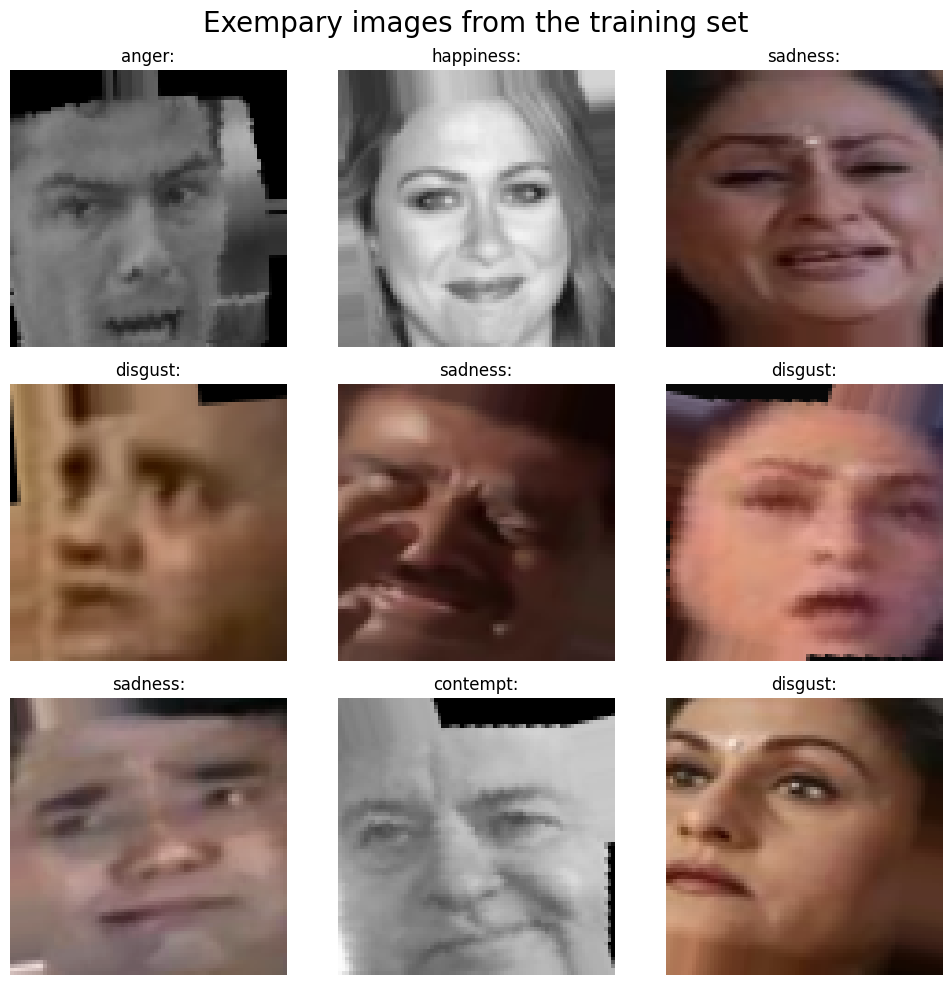

In [5]:
print(f"Classes: {train_set.class_indices}")

# Reverse the class_indices disctionary (np. 0 -> 'angry', 1 -> 'fear', ...)
class_labels = {v: k for k, v in train_set.class_indices.items()}

# Exempary images
plt.figure(figsize=(10, 10))
plt.suptitle("Exempary images from the training set", fontsize=20)
x_batch, y_batch = next(train_set)
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    label_index = np.argmax(y_batch[i])
    class_name = class_labels[label_index]
    plt.title(f"{class_name}:")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Adding class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_set.classes),
    y=train_set.classes
)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(1.0),
 1: np.float64(1.0),
 2: np.float64(1.0),
 3: np.float64(1.0),
 4: np.float64(1.0),
 5: np.float64(1.0),
 6: np.float64(1.0),
 7: np.float64(1.0)}

In [ ]:
# Face detection setup
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Function to detect and preprocess faces in images
def detect_face(image_path, target_size=(75, 75)):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)
    if len(faces) == 0:
        return None
    x, y, w, h = faces[0]
    face = img[y:y+h, x:x+w]
    face_resized = cv2.resize(face, target_size)
    return face_resized / 255.0


def load_dataset(data_dir, target_size=(75, 75)):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))

    for label in class_names:
        class_dir = os.path.join(data_dir, label)
        for filename in os.listdir(class_dir):
            img_path = os.path.join(class_dir, filename)
            face = detect_face(img_path, target_size)
            if face is not None:
                images.append(face)
                labels.append(label)

    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    one_hot_labels = to_categorical(labels_encoded, num_classes=len(le.classes_))

    return np.array(images), one_hot_labels, le

X_train, y_train, label_encoder = load_dataset(train_path, target_size)
X_val, y_val, _ = load_dataset(val_path, target_size)
X_test, y_test, _ = load_dataset(test_path, target_size)

# Print dataset shapes
print("✅ Train data:", X_train.shape, y_train.shape)
print("✅ Val data:", X_val.shape, y_val.shape)
print("✅ Test data:", X_test.shape, y_test.shape)

🔄 Wczytywanie danych treningowych...
🔄 Wczytywanie danych walidacyjnych...
🔄 Wczytywanie danych testowych...
✅ Dane treningowe: (29752, 75, 75, 3) (29752, 8)
✅ Dane walidacyjne: (7421, 75, 75, 3) (7421, 8)
✅ Dane testowe: (4216, 75, 75, 3) (4216, 8)


In [8]:
model = Sequential([
    # Blok 1
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(75, 75, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    # Blok 2
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    # Blok 3
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    # Warstwy gęste
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

c:\Users\48668\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Callback that changes learning rate when model has stopped improving
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_set,
    steps_per_epoch=len(train_set),
    epochs=40,
    validation_data=val_set,
    validation_steps=len(val_set),
    class_weight=class_weights,
    callbacks=[reduce_lr]
)

c:\Users\48668\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1451s 1s/step - accuracy: 0.2968 - loss: 2.3632 - val_accuracy: 0.5957 - val_loss: 1.1899 - learning_rate: 1.0000e-04
Epoch 2/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1208s 977ms/step - accuracy: 0.4953 - loss: 1.4965 - val_accuracy: 0.6823 - val_loss: 0.8962 - learning_rate: 1.0000e-04
Epoch 3/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1277s 1s/step - accuracy: 0.5962 - loss: 1.1872 - val_accuracy: 0.7476 - val_loss: 0.6678 - learning_rate: 1.0000e-04
Epoch 4/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1210s 979ms/step - accuracy: 0.6631 - loss: 0.9718 - val_accuracy: 0.7886 - val_loss: 0.5672 - learning_rate: 1.0000e-04
Epoch 5/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1186s 960ms/step - accuracy: 0.7102 - loss: 0.8248 - val_accuracy: 0.8300 - val_loss: 0.4693 - learning_rate: 1.0000e-04
Epoch 6/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1169s 946ms/step - accuracy: 0.7370 - loss: 0.7251 - val_accuracy: 0.8510 - val_loss: 0.4147 - learning_rate: 1.0000e-04
Epoch 7/40
1236/1236 ━━━━━━━

In [10]:
loss, acc = model.evaluate(test_set)
print(f"\nAccuracy: {acc * 100:.2f}%")   

172/172 ━━━━━━━━━━━━━━━━━━━━ 89s 520ms/step - accuracy: 0.9887 - loss: 0.0359

Accuracy: 97.73%


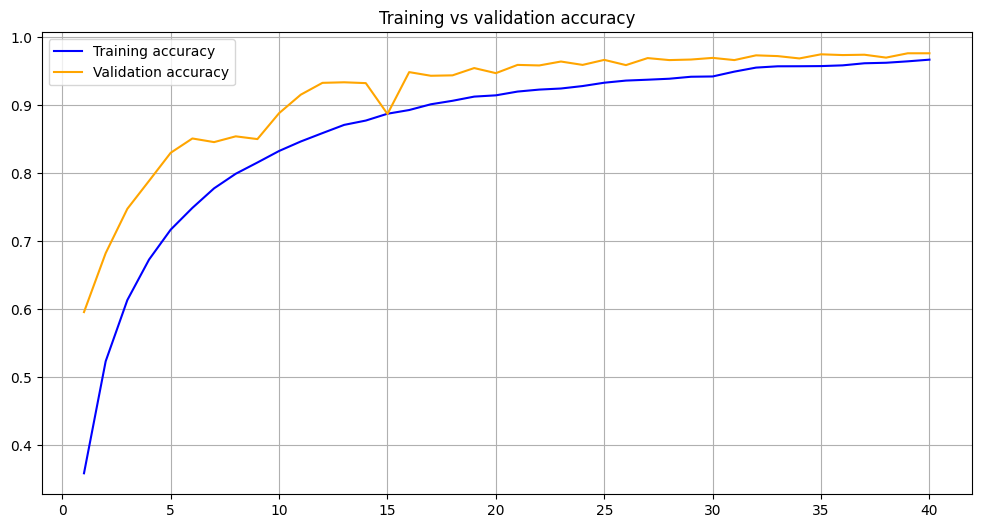

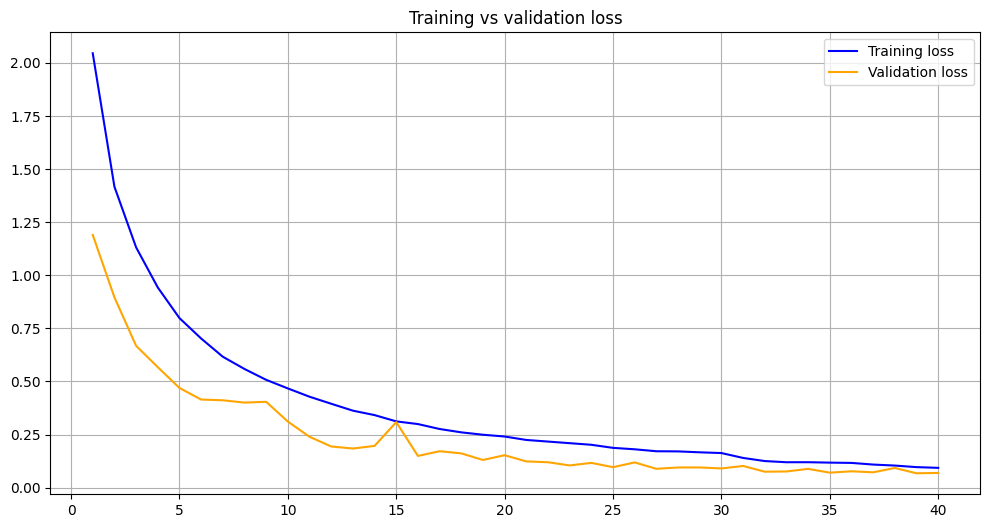

In [11]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(accuracy) + 1) # get the number of epochs for X axsis

plt.figure(figsize=(12, 6))
plt.plot(epochs, accuracy, color='blue', label='Training accuracy')
plt.plot(epochs, val_accuracy, color='orange', label='Validation accuracy')
plt.title('Training vs validation accuracy')
plt.grid(True)
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, color='blue', label='Training loss')
plt.plot(epochs, val_loss, color='orange', label='Validation loss')
plt.title('Training vs validation loss')
plt.grid(True)
plt.legend()

plt.show()

In [12]:
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
target_names = [class_labels[i] for i in range(len(class_labels))]
print(classification_report(test_set.classes, y_pred, target_names=target_names))

172/172 ━━━━━━━━━━━━━━━━━━━━ 43s 249ms/step
              precision    recall  f1-score   support

       anger       0.98      1.00      0.99       687
    contempt       1.00      1.00      1.00       687
     disgust       0.98      1.00      0.99       687
        fear       1.00      1.00      1.00       687
   happiness       0.96      0.90      0.93       687
     neutral       0.93      0.92      0.92       687
     sadness       0.98      1.00      0.99       687
    surprise       0.98      1.00      0.99       687

    accuracy                           0.98      5496
   macro avg       0.98      0.98      0.98      5496
weighted avg       0.98      0.98      0.98      5496



In [13]:
model.save("emotion_cnn_model.h5")
print("✅ Model was saved as emotion_cnn_model.h5")

✅ Model was saved as emotion_cnn_model.h5


In [1]:
pip install lime

     -------------------------------------- 275.7/275.7 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 78.5/78.5 kB ? eta 0:00:00
     ---------------------------------------- 12.8/12.8 MB 1.7 MB/s eta 0:00:00
     ---------------------------------------- 2.0/2.0 MB 1.9 MB/s eta 0:00:00
     -------------------------------------- 315.8/315.8 kB 3.3 MB/s eta 0:00:00
     -------------------------------------- 230.8/230.8 kB 7.1 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283840 sha256=2f58e356ba339fada4742164c0ca9d8c9860760bc6ff169e04e489b1dcb45fc7
  Stored in directory: c:\users\48668\appdata\local\pip\cache\wheels\26\41\d9\b7a236e989a8dcc8a26f1e45a937ad3658bc0dd5e94bac38a5
Successfully built lime
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
